## **Aprendizaje No Supervisado: Algoritmos de Clustering**  

### **1. Introducción al Aprendizaje No Supervisado**  
📌 **Objetivo:** Comprender qué es el aprendizaje no supervisado y cómo se diferencia del aprendizaje supervisado.  

📌 **Explicación:**  
- En **aprendizaje supervisado**, se entrenan modelos con datos etiquetados (ejemplo: imágenes con sus respectivas categorías).  
- En **aprendizaje no supervisado**, el modelo encuentra estructuras o patrones en datos sin etiquetas.  
- **Aplicaciones principales**: Segmentación de clientes, compresión de datos, detección de anomalías.  

📌 **Ejemplo:**  
Un algoritmo no supervisado podría analizar patrones de compra en un supermercado y descubrir grupos de clientes con hábitos similares, sin que nadie defina esas categorías previamente.  

---

### **2. ¿Qué es el Clustering?**  
📌 **Definición:**  
- El **clustering** agrupa datos en subconjuntos llamados **clusters**, donde los objetos dentro de un mismo cluster son más similares entre sí que con los de otros clusters.  
- No hay una única forma de definir qué significa "ser similar", lo que lleva a distintos algoritmos de clustering.  

📌 **Aplicaciones:**  
- Agrupación de clientes para marketing.  
- Identificación de comunidades en redes sociales.  
- Análisis de imágenes y segmentación de objetos.  

---

### **3. Principales Algoritmos de Clustering**  

#### **📍 K-Means**  
📌 **Explicación:**  
- Se eligen **K centroides** al azar.  
- Cada punto se asigna al centroide más cercano.  
- Se recalculan los centroides hasta que los grupos dejen de cambiar.  

📌 **Ventajas:**  
✅ Rápido y eficiente para grandes volúmenes de datos.  
✅ Fácil de entender e implementar.  

📌 **Desventajas:**  
❌ Se debe definir el número de clusters **K** previamente.  
❌ No funciona bien con datos de formas complejas (ejemplo: clusters con formas alargadas o irregulares).  

📌 **Ejemplo práctico:**  
Si analizamos transacciones en un banco, K-Means puede encontrar grupos de clientes con hábitos de gasto similares.  

---

#### **📍 DBSCAN (Density-Based Spatial Clustering of Applications with Noise)**  
📌 **Explicación:**  
- Agrupa puntos densamente conectados y deja fuera los puntos aislados como "ruido".  
- No requiere definir el número de clusters de antemano.  

📌 **Ventajas:**  
✅ Identifica clusters de formas arbitrarias.  
✅ Detecta puntos atípicos (outliers).  

📌 **Desventajas:**  
❌ Puede ser sensible a los parámetros de configuración.  
❌ No funciona bien con datos de densidad variable.  

📌 **Ejemplo práctico:**  
Si analizamos la distribución de terremotos en un mapa, DBSCAN podría detectar zonas de alta actividad sísmica sin necesidad de definir cuántas hay.  

---

#### **📍 Algoritmo de Clustering Jerárquico**  
📌 **Explicación:**  
- Crea una estructura en forma de árbol (**dendrograma**) donde los clusters se agrupan progresivamente.  
- Puede ser **aglomerativo** (se inicia con puntos individuales y se agrupan) o **divisivo** (se parte de un solo cluster y se divide en subgrupos).  

📌 **Ventajas:**  
✅ No requiere especificar el número de clusters de antemano.  
✅ Se puede visualizar fácilmente la estructura de los datos.  

📌 **Desventajas:**  
❌ Computacionalmente costoso para grandes volúmenes de datos.  
❌ Puede ser difícil decidir dónde cortar la jerarquía.  

📌 **Ejemplo práctico:**  
Se usa en biología para construir **árboles filogenéticos** que muestran relaciones entre especies.  

---

#### **📍 Modelo de Mezclas Gaussianas (GMM - Gaussian Mixture Model)**  
📌 **Explicación:**  
- Supone que los datos provienen de una combinación de **varias distribuciones gaussianas**.  
- En lugar de asignar cada punto a un solo cluster, GMM calcula la **probabilidad** de que un punto pertenezca a cada cluster.  

📌 **Ventajas:**  
✅ Puede modelar clusters con formas más complejas (no solo esféricos).  
✅ Permite una clasificación **probabilística** en lugar de una clasificación rígida.  

📌 **Desventajas:**  
❌ Es más costoso computacionalmente que K-Means.  
❌ Puede ser sensible a valores iniciales y requiere estimación de parámetros.  

📌 **Ejemplo práctico:**  
Si analizamos tonos de piel en imágenes, GMM puede identificar diferentes tonos sin una separación rígida entre ellos, lo que ayuda en la segmentación de piel en imágenes.  

---

### **4. Comparación de Algoritmos**  
| Algoritmo  | Parámetros previos | Forma de clusters | Manejo de outliers | Escalabilidad |
|------------|-------------------|-------------------|---------------------|--------------|
| **K-Means** | K (número de clusters) | Esféricos | No | Alta |
| **DBSCAN** | Distancia mínima, puntos mínimos | Arbitraria | Sí | Media |
| **Jerárquico** | Ninguno o número de cortes | Arbitraria | No | Baja |
| **GMM** | Número de mezclas | Elípticos/Gaussianos | No | Media |

---

### **5. Ejemplo con Sklearn**  
📌 **Objetivo:** Aplicar K-Means y GMM en un conjunto de datos simulado.  

✅ **Ejemplo en Python con `sklearn`**  


In [1]:
try:
    import numpy as np
except ImportError:
    %pip install numpy
    import numpy as np
try:
    import matplotlib.pyplot as plt
except ImportError:
    %pip install matplotlib
    import matplotlib.pyplot as plt
try:
    from sklearn.mixture import GaussianMixture
except ImportError:
    %pip install scikit-learn
    from sklearn.mixture import GaussianMixture
try:
    from sklearn.datasets import make_blobs
except ImportError:
    %pip install scikit-learn
    from sklearn.datasets import make_blobs

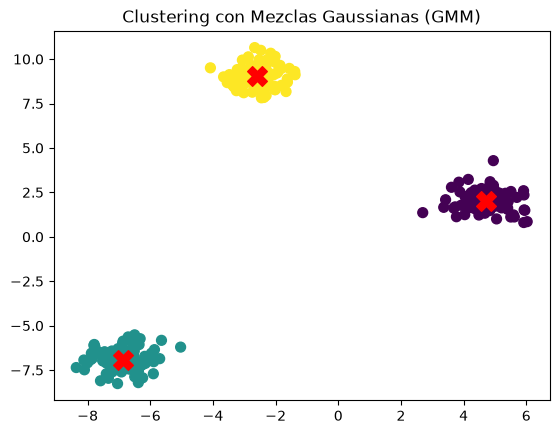

In [2]:
# Generar datos sintéticos
X, _ = make_blobs(n_samples=300, centers=3, cluster_std=0.60, random_state=42)

# Aplicar GMM
gmm = GaussianMixture(n_components=3, covariance_type='full')
gmm.fit(X)
y_gmm = gmm.predict(X)

# Graficar los clusters
plt.scatter(X[:, 0], X[:, 1], c=y_gmm, cmap='viridis', s=50)
plt.scatter(gmm.means_[:, 0], gmm.means_[:, 1], s=200, c='red', marker='X')
plt.title("Clustering con Mezclas Gaussianas (GMM)")
plt.show()


## **¿Cuándo usar cada algoritmo de clustering?**  

### **📍 K-Means**  
✔️ **Cuándo usarlo:**  
- Cuando los clusters son aproximadamente **esféricos** y tienen tamaños similares.  
- Cuando se necesita un algoritmo **rápido y eficiente** para grandes volúmenes de datos.  
- Cuando se conoce o se puede estimar el número de clusters **K**.  

❌ **Cuándo NO usarlo:**  
- Si los clusters tienen formas complejas o densidades variables.  
- Si hay muchos **outliers**, ya que K-Means es sensible a ellos.  
- Si el número de clusters es difícil de definir.  

**🔹 Ejemplo de uso:**  
- **Segmentación de clientes**: Agrupar clientes en diferentes categorías según su comportamiento de compra.  
- **Compresión de imágenes**: Reducir la cantidad de colores en una imagen segmentando en K grupos.  

---

### **📍 DBSCAN (Density-Based Spatial Clustering of Applications with Noise)**  
✔️ **Cuándo usarlo:**  
- Cuando los datos tienen **formas complejas** y no siguen una distribución esférica.  
- Si hay **outliers**, ya que DBSCAN los identifica y los marca como "ruido".  
- Cuando el número de clusters es **desconocido** y difícil de estimar.  

❌ **Cuándo NO usarlo:**  
- Si los datos tienen **densidades muy variables**, porque DBSCAN podría no separar bien los clusters.  
- Si se necesita analizar **grandes volúmenes de datos**, ya que puede ser computacionalmente costoso.  

**🔹 Ejemplo de uso:**  
- **Detección de comunidades en redes sociales**: Identificar grupos de personas conectadas de forma densa en una red social.  
- **Análisis de tráfico urbano**: Identificar zonas de congestión sin necesidad de definir cuántas hay.  
- **Detección de fraudes**: Encontrar transacciones atípicas en un sistema financiero.  

---

### **📍 Clustering Jerárquico**  
✔️ **Cuándo usarlo:**  
- Cuando se quiere analizar **la relación entre los clusters** a diferentes niveles de granularidad.  
- Si no se conoce el número de clusters de antemano y se quiere explorar la estructura de los datos.  
- Cuando el conjunto de datos no es muy grande, ya que el costo computacional puede ser alto.  

❌ **Cuándo NO usarlo:**  
- Si el conjunto de datos es **muy grande** y no se dispone de suficiente poder de cómputo.  
- Si los clusters tienen **formas muy irregulares**, ya que otros métodos como DBSCAN podrían funcionar mejor.  

**🔹 Ejemplo de uso:**  
- **Biología y genética**: Construcción de **árboles filogenéticos** para clasificar especies según similitudes genéticas.  
- **Análisis de documentos**: Agrupar artículos de prensa en categorías según similitudes en el contenido.  
- **Agrupación de productos**: Organizar productos de una tienda en categorías de forma jerárquica.  

---

### **📍 Modelo de Mezclas Gaussianas (GMM - Gaussian Mixture Model)**  
✔️ **Cuándo usarlo:**  
- Cuando los datos tienen una **distribución elíptica o gaussiana** en lugar de ser perfectamente esféricos.  
- Si se necesita un **clustering probabilístico**, es decir, que un punto pueda pertenecer a varios clusters con distintas probabilidades.  
- Si los clusters tienen **tamaños y formas diferentes**.  

❌ **Cuándo NO usarlo:**  
- Si hay **muchos datos** y se requiere eficiencia computacional (GMM es más costoso que K-Means).  
- Si los clusters tienen formas demasiado irregulares que no pueden modelarse con distribuciones gaussianas.  

**🔹 Ejemplo de uso:**  
- **Reconocimiento de voz**: Modelar diferentes sonidos de voz en aplicaciones de reconocimiento de patrones.  
- **Segmentación de imágenes médicas**: Identificar diferentes tejidos en una resonancia magnética.  
- **Análisis de datos financieros**: Modelar el comportamiento de diferentes perfiles de inversión en mercados bursátiles.  

---

## **Comparación Resumida**  

| Algoritmo  | Forma de Clusters | Escalabilidad | Manejo de Outliers | Requiere definir número de clusters |
|------------|------------------|--------------|--------------------|----------------------|
| **K-Means** | Esféricos | Alta | No | Sí |
| **DBSCAN** | Arbitraria | Media | Sí | No |
| **Jerárquico** | Arbitraria | Baja | No | No |
| **GMM** | Elípticos/Gaussianos | Media | No | Sí |

---

## **Conclusión**  
- **Si los clusters son esféricos y el número de grupos es conocido**, usa **K-Means**.  
- **Si los clusters tienen formas complejas y hay outliers**, usa **DBSCAN**.  
- **Si necesitas un análisis jerárquico y los datos no son muy grandes**, usa **clustering jerárquico**.  
- **Si los clusters tienen formas elípticas y necesitas una clasificación probabilística**, usa **GMM**.  


## **📚 Libros de Referencia sobre Clustering**  

### **1️⃣ Pattern Recognition and Machine Learning** – Christopher M. Bishop  
🔹 **Descripción:**  
Uno de los libros más completos sobre **aprendizaje automático**, con un enfoque matemático riguroso. Explica en detalle el **Modelo de Mezclas Gaussianas (GMM)** y otros métodos de clustering.  

🔹 **Ideal para:**  
- Lectores con conocimientos matemáticos avanzados.  
- Entender la base probabilística de algoritmos como GMM.  

🔹 **Disponibilidad:**  
Este libro está disponible en formato físico en la **Biblioteca de la Universidad del Norte**.  

---

### **2️⃣ Introduction to Machine Learning with Python** – Deepti Chopra & Roopal Khurana (2023)  
🔹 **Descripción:**  
Este libro ofrece una introducción clara al **aprendizaje automático con Python**, con enfoque en herramientas prácticas como `scikit-learn`. Incluye una exploración de **K-Means, DBSCAN y otros algoritmos de clustering** con ejemplos y casos de estudio.  

🔹 **Ideal para:**  
- Estudiantes y profesionales que buscan una introducción moderna y aplicada.  
- Aplicaciones en ciencia de datos con Python.  

🔹 **Enlace:** [🔗 ProQuest Ebook Central (Requiere acceso institucional)](https://ebookcentral-proquest-com.ezproxy.uninorte.edu.co/lib/unorte-ebooks/detail.action?docID=30410702)  

---

### **3️⃣ Data Mining, Southeast Asia Edition** – Jiawei Han, Jian Pei & Micheline Kamber (2006)  
🔹 **Descripción:**  
Un libro fundamental para **minería de datos**, con un capítulo dedicado a **clustering**. Explica en detalle métodos como **K-Means, DBSCAN y clustering jerárquico**, con aplicaciones en grandes volúmenes de datos.  

🔹 **Ideal para:**  
- Quienes buscan aplicaciones de clustering en **Big Data**.  
- Comprender cómo elegir el algoritmo adecuado según el tipo de datos.  

🔹 **Enlace:** [🔗 EBSCO Research (Requiere acceso institucional)](https://research-ebsco-com.ezproxy.uninorte.edu.co/linkprocessor/plink?id=ea8e27f7-c6df-324d-a1d5-3cd4170e1a3d) *(Accedido el 18 de marzo de 2025)*.  

---

## **📌 También están disponibles libros y artículos en la Biblioteca de la Universidad del Norte**  
Además de estos libros, puedes encontrar **artículos científicos, libros electrónicos y otros recursos** relacionados con clustering en la **Biblioteca de la Universidad del Norte**. Se recomienda consultar su catálogo en línea o visitar la biblioteca para más información.  

🔹 **Enlace al catálogo de la Biblioteca:** [🔗 Biblioteca Uninorte](https://biblioteca.uninorte.edu.co) *(si disponible en línea)*  
